In [51]:
import numpy as np
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


In [52]:
#read the dataset
df = pd.read_csv("dataset/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [53]:
# Check for duplicates in the dataset
df.duplicated().sum()

np.int64(1202)

In [54]:
# View the duplicate rows to understand which entries are repeated and if they need to be addressed (e.g., by removing or consolidating them).
df[df.duplicated(keep=False)].sort_values(
    by=["name", "year"]
).head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1977,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
7324,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
2129,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
7775,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
131,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1561,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1857,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
3236,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
5245,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
7699,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0


In [55]:
#Since they are completely identical, we can drop the duplicates to avoid biasing our model with repeated data points.
df = df.drop_duplicates()

In [56]:
# Check the distribution of the 'owner' column
df['owner'].value_counts()

owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64

In [57]:
# Map the 'owner' column to numerical values
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}

df["owner"] = df["owner"].map(owner_mapping)

In [58]:
#display the first few rows of the DataFrame to verify the changes
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,3,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,1,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,1,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [59]:
# Check the distribution of the 'owner' column to ensure the mapping was successful
df['owner'].value_counts()

owner
1    4242
2    1974
3     536
4     169
5       5
Name: count, dtype: int64

In [60]:
# Check the unique values in the 'fuel' column
df['fuel'].unique()

<ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

In [61]:
# Remove rows with specific fuel types, as they use a different mileage system
remove_values = ["CNG", "LPG"]
df = df[~df["fuel"].isin(remove_values)]

In [62]:
# Check the unique values in the 'fuel' column after removing the specified fuel types
df['fuel'].unique()

<ArrowStringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

In [63]:
# Check the first few rows of the 'mileage' column and its data type
print(df["mileage"].head())
print(df["mileage"].dtype)

0     23.4 kmpl
1    21.14 kmpl
2     17.7 kmpl
3     23.0 kmpl
4     16.1 kmpl
Name: mileage, dtype: str
str


In [64]:
# Check for missing values in the 'mileage' column
df["mileage"].isna().sum()

np.int64(201)

In [65]:
# Display rows with missing values in the 'mileage' column
# do not handle the NaN value yet. just display the rows with NaN values in the mileage column to understand the data better.
df[df["mileage"].isnull()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
13,Maruti Swift 1.3 VXi,2007,200000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
31,Fiat Palio 1.2 ELX,2003,70000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
78,Tata Indica DLS,2003,50000,70000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN,NaN
87,Maruti Swift VDI BSIV W ABS,2015,475000,78000,Diesel,Dealer,Manual,1,NaN,NaN,NaN,NaN,NaN
119,Maruti Swift VDI BSIV,2010,300000,120000,Diesel,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7740,Hyundai Santro Xing XG,2004,70000,70000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
7996,Hyundai Santro LS zipPlus,2000,140000,50000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
8009,Hyundai Santro Xing XS eRLX Euro III,2006,145000,80000,Petrol,Individual,Manual,2,NaN,NaN,NaN,NaN,NaN
8068,Ford Figo Aspire Facelift,2017,580000,165000,Diesel,Individual,Manual,1,NaN,NaN,NaN,NaN,NaN


In [66]:
# Check the shape of the DataFrame
df.shape

(6832, 13)

In [67]:
# Convert the 'mileage' column to float by extracting the numeric part and converting it to float
df["mileage"] = df.mileage.str.split().str[0].astype(float)

In [68]:
# Check the first few rows of the 'mileage' column and its data type to see if the conversion was successful
print(df["mileage"].head())
print(df["mileage"].dtype)

0    23.40
1    21.14
2    17.70
3    23.00
4    16.10
Name: mileage, dtype: float64
float64


In [69]:
# Convert the 'engine' column to float by extracting the numeric part and converting it to float
df["engine"] = df.engine.str.split().str[0].astype(float)

In [70]:
# Check the first few rows of the 'engine' column and its data type to see if the conversion was successful
print(df["engine"].head())
print(df["engine"].dtype)

0    1248.0
1    1498.0
2    1497.0
3    1396.0
4    1298.0
Name: engine, dtype: float64
float64


In [71]:
# Convert the 'max_power' column to float by extracting the numeric part and converting it to float
df["max_power"] = df["max_power"].str.split().str[0].astype(float)

In [72]:
#  Check the first few rows of the 'max_power' column and its data type to see if the conversion was successful
print(df["max_power"].head())
print(df["max_power"].dtype)

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64
float64


In [73]:
# Check the first few rows of the 'name' column and its data type

print(df["name"].head())
print(df["name"].dtype)

0          Maruti Swift Dzire VDI
1    Skoda Rapid 1.5 TDI Ambition
2        Honda City 2017-2020 EXi
3       Hyundai i20 Sportz Diesel
4          Maruti Swift VXI BSIII
Name: name, dtype: str
str


In [74]:
# Split the 'name' column to extract the first word (brand name) and assign it back to the 'name' column
df["name"] = df["name"].str.split().str[0]

In [75]:
# Check the first few rows of the 'name' column and its data type to see if the conversion was successful
print(df["name"].head())
print(df["name"].dtype)

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: name, dtype: object
object


In [76]:
# Drop the 'torque' column from the DataFrame, as it may not be relevant for the analysis or model training
df = df.drop("torque", axis=1)

In [77]:
# Check the columns of the DataFrame to verify the changes
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='str')

In [78]:
# Remove rows where the 'owner' column has a value of 5 (Test Drive Car), as they are ridiculously expensive
df = df[df["owner"] != 5]

In [79]:
# Check the distribution of the 'owner' column after removing the rows with 'Test Drive Car' to ensure the changes were successful
df['owner'].value_counts()

owner
1    4191
2    1943
3     528
4     165
Name: count, dtype: int64

In [80]:
# Check for any remaining missing values in the DataFrame
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
dtype: int64

In [81]:
# Check the shape of the DataFrame after all the preprocessing steps
df.shape

(6827, 12)

In [82]:
#There are 8,028 rows (samples) and 12 columns (features + target)
#We have 214 rows with missing values in some columns, which is only about 2.7% of the dataset. 
# I think it is reasonable to remove these rows since we would still retain about 97.3% of the data.
df = df.dropna()

In [83]:
#check if there are any missing values left
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [84]:
# Since selling_price is a big number, it can cause your prediction to be very unstable
# transform the target variable 'selling_price' using logarithm to reduce skewness and make it more normally distributed
y = np.log(df['selling_price'])

#drop the target variable from the feature set
X = df.drop("selling_price", axis=1)

In [85]:
#Split the dataset into training and testing sets, with 80% of the data used for training and 20% for testing. The random_state parameter is set to 42 to ensure reproducibility of the results.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
# Check the first few rows of the training set to ensure that the split was successful and the data looks as expected
X_train.head()

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
3890,Maruti,1995,70000,Petrol,Individual,Manual,1,16.10,796.0,37.0,4.0
6291,Maruti,2017,76000,Diesel,Dealer,Manual,1,25.47,1248.0,88.5,7.0
4492,Toyota,2015,190000,Diesel,Individual,Manual,1,12.99,2494.0,100.6,7.0
6794,Tata,2012,120000,Diesel,Individual,Manual,1,23.03,1396.0,69.0,5.0
2786,Tata,2015,120000,Diesel,Individual,Manual,2,19.10,1405.0,70.0,5.0


In [87]:
# Define the categorical features that need to be one-hot encoded
categorical_features = [
    "name",
    "fuel",
    "seller_type",
    "transmission"
]

# Create a ColumnTransformer to apply one-hot encoding to the categorical features while leaving the other features unchanged
# It is needed since the model cannot handle categorical features directly, and one-hot encoding is a common technique to convert categorical variables into a format that can be provided to machine learning algorithms to do a better job in prediction.
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [88]:
from utils import *
from regularization import LassoRegression
from sklearn.preprocessing import StandardScaler

In [89]:
import importlib
import regularization
import mlflow

regularization = importlib.reload(regularization)

from sklearn.model_selection import KFold
from regularization import (
    LinearRegression,
    NoRegularization,
    PolynomialRegression,
    LassoRegression,
    RidgeRegression
)

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("car-price-custom-regression")

cv = KFold(n_splits=3, shuffle=True, random_state=42)
best_models = []

Features:  Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='str')


In [90]:
model_configs = {
    "Normal": {
        "lr": 0.001,
        "method": "mini",
        "initialization": "zeros",
        "use_momentum": False
    },
    "Polynomial": {
        "degree": 2,
        "lr": 0.001,
        "method": "mini",
        "initialization": "zeros",
        "use_momentum": False
    },
    "Lasso": {
        "lr": 0.001,
        "method": "mini",
        "l": 0.001,
        "initialization": "zeros",
        "use_momentum": False
    },
    "Ridge": {
        "lr": 0.001,
        "method": "mini",
        "l": 0.001,
        "initialization": "zeros",
        "use_momentum": False
    }
}
model_names = list(model_configs)
results = {
    model_name: {"mse": [], "r2": []}
    for model_name in model_names
}

with mlflow.start_run(run_name="custom-regression-cross-validation") as parent_run:
    mlflow.log_params({
        "dataset": "Cars.csv",
        "target": "log(selling_price)",
        "outer_cv_folds": 3,
        "inner_cv_folds": 2,
        "random_state": 42
    })

    for model_name, config in model_configs.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({
                "model": model_name,
                **config
            })

            for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                if model_name == "Polynomial":
                    model = PolynomialRegression(
                        numeric_start=number_of_categorical_features,
                        **config
                    )
                elif model_name == "Normal":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LinearRegression(NoRegularization(), **config)
                elif model_name == "Lasso":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LassoRegression(**config)
                else:
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = RidgeRegression(**config)

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

                results[model_name]["mse"].append(mse)
                results[model_name]["r2"].append(r2)
                mlflow.log_metrics({"log_mse": mse, "log_r2": r2}, step=fold_number)

            mlflow.log_metrics({
                "mean_log_mse": np.mean(results[model_name]["mse"]),
                "mean_log_r2": np.mean(results[model_name]["r2"])
            })

comparison = pd.DataFrame({
    "Model": model_names,
    "MSE": [np.mean(results[name]["mse"]) for name in model_names],
    "R2": [np.mean(results[name]["r2"]) for name in model_names]
}).sort_values("R2", ascending=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_text(comparison.to_csv(index=False), "comparison.csv")
    mlflow.log_metric("best_mean_log_r2", float(comparison.iloc[0]["R2"]))
    mlflow.set_tag("best_model", comparison.iloc[0]["Model"])

best_models.append({
    "key": "Mini_Without_Momentum",
    "model": comparison.iloc[0]["Model"],
    "r2": comparison.iloc[0]["R2"]
})
print("Without Momentum, the best model based on R2 is:", comparison.iloc[0]["Model"])

comparison




Fold 0: 0.4564167484699512
Fold 1: 0.7708573724438376
Fold 0: 0.28921942642898113
Fold 1: 0.5654748191227347
Fold 0: 0.3997230765319135
Fold 1: 0.369007322944626
Fold 0: 0.5737172463860667
Fold 1: 0.8608325670279324
Fold 0: 0.5516529964442245
Fold 1: 0.6295621897173085
Fold 0: 0.437099148015875
Fold 1: 0.4746845256569075
Fold 0: 0.3918539904614041
Fold 1: 0.6683217986837987
Fold 0: 0.25769337232475514
Fold 1: 0.4988005325308315
Fold 0: 0.3277927737729839
Fold 1: 0.3120552690135757
Fold 0: 0.45611207469097587
Fold 1: 0.7708461599036395
Fold 0: 0.2921325481817567
Fold 1: 0.5644003069357464
Fold 0: 0.3994989520096404
Fold 1: 0.36946581737943296
Without Momentum, the best model based on R2 is: Lasso


,Model,MSE,R2
2,Lasso,0.304639,0.453666
0,Normal,0.355564,0.362597
3,Ridge,0.355747,0.362294
1,Polynomial,0.402466,0.278959


In [91]:
model_configs = {
    "Normal": {
        "lr": 0.001,
        "method": "mini",
        "initialization": "zeros",
        "use_momentum": True
    },
    "Polynomial": {
        "degree": 2,
        "lr": 0.001,
        "method": "mini",
        "initialization": "zeros",
        "use_momentum": True
    },
    "Lasso": {
        "lr": 0.001,
        "method": "mini",
        "l": 0.001,
        "initialization": "zeros",
        "use_momentum": True
    },
    "Ridge": {
        "lr": 0.001,
        "method": "mini",
        "l": 0.001,
        "initialization": "zeros",
        "use_momentum": True
    }
}
model_names = list(model_configs)
results = {
    model_name: {"mse": [], "r2": []}
    for model_name in model_names
}

with mlflow.start_run(run_name="custom-regression-cross-validation") as parent_run:
    mlflow.log_params({
        "dataset": "Cars.csv",
        "target": "log(selling_price)",
        "outer_cv_folds": 3,
        "inner_cv_folds": 2,
        "random_state": 42
    })

    for model_name, config in model_configs.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({
                "model": model_name,
                **config
            })

            for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                if model_name == "Polynomial":
                    model = PolynomialRegression(
                        numeric_start=number_of_categorical_features,
                        **config
                    )
                elif model_name == "Normal":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LinearRegression(NoRegularization(), **config)
                elif model_name == "Lasso":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LassoRegression(**config)
                else:
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = RidgeRegression(**config)

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

                results[model_name]["mse"].append(mse)
                results[model_name]["r2"].append(r2)
                mlflow.log_metrics({"log_mse": mse, "log_r2": r2}, step=fold_number)

            mlflow.log_metrics({
                "mean_log_mse": np.mean(results[model_name]["mse"]),
                "mean_log_r2": np.mean(results[model_name]["r2"])
            })

comparison = pd.DataFrame({
    "Model": model_names,
    "MSE": [np.mean(results[name]["mse"]) for name in model_names],
    "R2": [np.mean(results[name]["r2"]) for name in model_names]
}).sort_values("R2", ascending=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_text(comparison.to_csv(index=False), "comparison.csv")
    mlflow.log_metric("best_mean_log_r2", float(comparison.iloc[0]["R2"]))
    mlflow.set_tag("best_model", comparison.iloc[0]["Model"])

best_models.append({
    "key": "Mini_With_Momentum",
    "model": comparison.iloc[0]["Model"],
    "r2": comparison.iloc[0]["R2"]
})
print("With Momentum, the best model based on mean log R2 is:", comparison.iloc[0]["Model"])
comparison

Fold 0: 2.4594885535502478
Fold 1: 2.771366169588911
Fold 0: 2.582506967596577
Fold 1: 2.647679935231943
Fold 0: 2.3916118861403657
Fold 1: 2.4109677646269008
Fold 0: 68.67103972813022
Fold 1: 68.77935334523312
Fold 0: 70.2400185892427
Fold 1: 69.32804490886815
Fold 0: 68.74388556554891
Fold 1: 68.81438946039876
Fold 0: 2.4530264739029644
Fold 1: 2.758459818535217
Fold 0: 2.577704775967892
Fold 1: 2.647693346182588
Fold 0: 2.3813530805922016
Fold 1: 2.406159612014137
Fold 0: 2.506396703686777
Fold 1: 2.8146077330092494
Fold 0: 2.6315461312113726
Fold 1: 2.705245623732698
Fold 0: 2.436496233094447
Fold 1: 2.4637732999907396
With Momentum, the best model based on mean log R2 is: Lasso


,Model,MSE,R2
2,Lasso,2.333509,-3.170275
0,Normal,2.335252,-3.173555
3,Ridge,2.385435,-3.262958
1,Polynomial,68.296306,-120.988940


In [92]:
model_configs = {
    "Normal": {
        "lr": 0.001,
        "method": "mini",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Polynomial": {
        "degree": 2,
        "lr": 0.001,
        "method": "mini",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Lasso": {
        "lr": 0.001,
        "method": "mini",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    },
    "Ridge": {
        "lr": 0.001,
        "method": "mini",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    }
}
model_names = list(model_configs)
results = {
    model_name: {"mse": [], "r2": []}
    for model_name in model_names
}

with mlflow.start_run(run_name="custom-regression-cross-validation") as parent_run:
    mlflow.log_params({
        "dataset": "Cars.csv",
        "target": "log(selling_price)",
        "outer_cv_folds": 3,
        "inner_cv_folds": 2,
        "random_state": 42
    })

    for model_name, config in model_configs.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({
                "model": model_name,
                **config
            })

            for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                if model_name == "Polynomial":
                    model = PolynomialRegression(
                        numeric_start=number_of_categorical_features,
                        **config
                    )
                elif model_name == "Normal":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LinearRegression(NoRegularization(), **config)
                elif model_name == "Lasso":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LassoRegression(**config)
                else:
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = RidgeRegression(**config)

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

                results[model_name]["mse"].append(mse)
                results[model_name]["r2"].append(r2)
                mlflow.log_metrics({"log_mse": mse, "log_r2": r2}, step=fold_number)

            mlflow.log_metrics({
                "mean_log_mse": np.mean(results[model_name]["mse"]),
                "mean_log_r2": np.mean(results[model_name]["r2"])
            })

comparison = pd.DataFrame({
    "Model": model_names,
    "MSE": [np.mean(results[name]["mse"]) for name in model_names],
    "R2": [np.mean(results[name]["r2"]) for name in model_names]
}).sort_values("R2", ascending=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_text(comparison.to_csv(index=False), "comparison.csv")
    mlflow.log_metric("best_mean_log_r2", float(comparison.iloc[0]["R2"]))
    mlflow.set_tag("best_model", comparison.iloc[0]["Model"])
best_models.append({
    "key": "Mini_xavier",
    "model": comparison.iloc[0]["Model"],
    "r2": comparison.iloc[0]["R2"]
})

print("With xavier, the best model based on mean log R2 is:", comparison.iloc[0]["Model"])
comparison

Fold 0: 0.4085811215412634
Fold 1: 0.7069055131488884
Fold 0: 0.23228608333724626
Fold 1: 0.7001747704583344
Fold 0: 0.3886038912690819
Fold 1: 0.3499055392256078
Fold 0: 0.34568882383273647
Fold 1: 0.9286379052877602
Fold 0: 0.550721770371612
Fold 1: 0.6594767423063157
Fold 0: 0.4628116937483482
Fold 1: 0.5850666201267801
Fold 0: 0.38038234796461284
Fold 1: 0.7697627146061237
Fold 0: 0.33410038024859934
Fold 1: 0.4799560880368526
Fold 0: 0.361207310980538
Fold 1: 0.45382152523227653
Fold 0: 0.6701486868432143
Fold 1: 0.7303235291857909
Fold 0: 0.30738503881898516
Fold 1: 0.8106019650871732
Fold 0: 0.3165474900216246
Fold 1: 0.38433511980880003
With xavier, the best model based on mean log R2 is: Normal


,Model,MSE,R2
0,Normal,0.354076,0.367475
3,Ridge,0.422225,0.252703
2,Lasso,0.443690,0.209020
1,Polynomial,0.448489,0.192290


In [93]:
model_configs = {
    "Normal": {
        "lr": 0.01,
        "method": "mini",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Polynomial": {
        "degree": 2,
        "lr": 0.01,
        "method": "mini",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Lasso": {
        "lr": 0.01,
        "method": "mini",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    },
    "Ridge": {
        "lr": 0.01,
        "method": "mini",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    }
}
model_names = list(model_configs)
results = {
    model_name: {"mse": [], "r2": []}
    for model_name in model_names
}

with mlflow.start_run(run_name="custom-regression-cross-validation") as parent_run:
    mlflow.log_params({
        "dataset": "Cars.csv",
        "target": "log(selling_price)",
        "outer_cv_folds": 3,
        "inner_cv_folds": 2,
        "random_state": 42
    })

    for model_name, config in model_configs.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({
                "model": model_name,
                **config
            })

            for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                if model_name == "Polynomial":
                    model = PolynomialRegression(
                        numeric_start=number_of_categorical_features,
                        **config
                    )
                elif model_name == "Normal":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LinearRegression(NoRegularization(), **config)
                elif model_name == "Lasso":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LassoRegression(**config)
                else:
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = RidgeRegression(**config)

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

                results[model_name]["mse"].append(mse)
                results[model_name]["r2"].append(r2)
                mlflow.log_metrics({"log_mse": mse, "log_r2": r2}, step=fold_number)

            mlflow.log_metrics({
                "mean_log_mse": np.mean(results[model_name]["mse"]),
                "mean_log_r2": np.mean(results[model_name]["r2"])
            })

comparison = pd.DataFrame({
    "Model": model_names,
    "MSE": [np.mean(results[name]["mse"]) for name in model_names],
    "R2": [np.mean(results[name]["r2"]) for name in model_names]
}).sort_values("R2", ascending=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_text(comparison.to_csv(index=False), "comparison.csv")
    mlflow.log_metric("best_mean_log_r2", float(comparison.iloc[0]["R2"]))
    mlflow.set_tag("best_model", comparison.iloc[0]["Model"])

best_models.append({
    "key": "Mini_xavier_lr01",
    "model": comparison.iloc[0]["Model"],
    "r2": comparison.iloc[0]["R2"]
})
print("With Learning Rate 0.01, the best model based on mean log R2 is:", comparison.iloc[0]["Model"])

comparison



Fold 0: 0.19006752307447672
Fold 1: 0.7554982958283373
Fold 0: 0.23686312610188578
Fold 1: 0.5104078779963025
Fold 0: 0.2337307067033814
Fold 1: 0.18782592036533327
Fold 0: 0.4886733015290371
Fold 1: 0.98164200314478
Fold 0: 0.388435384293
Fold 1: 0.6907742907882048
Fold 0: 0.4220595458394864
Fold 1: 0.48400019563952895
Fold 0: 0.30176477668538876
Fold 1: 0.10737309988554708
Fold 0: 0.17362391428702212
Fold 1: 0.2820136274869752
Fold 0: 0.066734848641984
Fold 1: 0.10527004487636031
Fold 0: 0.2236574165735403
Fold 1: 0.6846514806764773
Fold 0: 0.21715141619472103
Fold 1: 0.6487994179427938
Fold 0: 0.5225456839778445
Fold 1: 0.4078059626944914
With Learning Rate 0.01, the best model based on mean log R2 is: Lasso


,Model,MSE,R2
2,Lasso,0.108405,0.808668
0,Normal,0.244120,0.557169
3,Ridge,0.380412,0.329504
1,Polynomial,0.466870,0.175874


In [94]:
model_configs = {
    "Normal": {
        "lr": 0.0001,
        "method": "mini",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Polynomial": {
        "degree": 2,
        "lr": 0.0001,
        "method": "mini",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Lasso": {
        "lr": 0.0001,
        "method": "mini",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    },
    "Ridge": {
        "lr": 0.0001,
        "method": "mini",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    }
}
model_names = list(model_configs)
results = {
    model_name: {"mse": [], "r2": []}
    for model_name in model_names
}

with mlflow.start_run(run_name="custom-regression-cross-validation") as parent_run:
    mlflow.log_params({
        "dataset": "Cars.csv",
        "target": "log(selling_price)",
        "outer_cv_folds": 3,
        "inner_cv_folds": 2,
        "random_state": 42
    })

    for model_name, config in model_configs.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({
                "model": model_name,
                **config
            })

            for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                if model_name == "Polynomial":
                    model = PolynomialRegression(
                        numeric_start=number_of_categorical_features,
                        **config
                    )
                elif model_name == "Normal":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LinearRegression(NoRegularization(), **config)
                elif model_name == "Lasso":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LassoRegression(**config)
                else:
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = RidgeRegression(**config)

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

                results[model_name]["mse"].append(mse)
                results[model_name]["r2"].append(r2)
                mlflow.log_metrics({"log_mse": mse, "log_r2": r2}, step=fold_number)

            mlflow.log_metrics({
                "mean_log_mse": np.mean(results[model_name]["mse"]),
                "mean_log_r2": np.mean(results[model_name]["r2"])
            })

comparison = pd.DataFrame({
    "Model": model_names,
    "MSE": [np.mean(results[name]["mse"]) for name in model_names],
    "R2": [np.mean(results[name]["r2"]) for name in model_names]
}).sort_values("R2", ascending=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_text(comparison.to_csv(index=False), "comparison.csv")
    mlflow.log_metric("best_mean_log_r2", float(comparison.iloc[0]["R2"]))
    mlflow.set_tag("best_model", comparison.iloc[0]["Model"])

best_models.append({
    "key": "Mini_xavier_lr0001",
    "model": comparison.iloc[0]["Model"],
    "r2": comparison.iloc[0]["R2"]
})
print("With Learning Rate 0.0001, the best model based on mean log R2 is:", comparison.iloc[0]["Model"])

comparison



Fold 0: 2.646328077197603
Fold 1: 2.500219029329006
Fold 0: 2.5251367374754454
Fold 1: 2.5037846360295997
Fold 0: 2.4264758216514557
Fold 1: 2.5694352737860013
Fold 0: 69.35305292192405
Fold 1: 68.36164308076023
Fold 0: 70.44002167249523
Fold 1: 69.72814192926948
Fold 0: 67.90845379049946
Fold 1: 68.7876858587075
Fold 0: 2.658099570564797
Fold 1: 2.790040459158026
Fold 0: 2.708357923989169
Fold 1: 2.6042140689595716
Fold 0: 2.211246157819339
Fold 1: 2.531435796604955
Fold 0: 2.704221770442639
Fold 1: 3.2695853788755
Fold 0: 2.5043684900677694
Fold 1: 3.0056856867488118
Fold 0: 2.2850966675737197
Fold 1: 2.4085513007512374
With Learning Rate 0.0001, the best model based on mean log R2 is: Lasso


,Model,MSE,R2
2,Lasso,2.395759,-3.274353
0,Normal,2.406744,-3.281976
3,Ridge,2.489267,-3.467759
1,Polynomial,68.157152,-120.728100


In [95]:
model_configs = {
    "Normal": {
        "lr": 0.001,
        "method": "batch",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Polynomial": {
        "degree": 2,
        "lr": 0.001,
        "method": "batch",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Lasso": {
        "lr": 0.001,
        "method": "batch",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    },
    "Ridge": {
        "lr": 0.001,
        "method": "batch",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    }
}
model_names = list(model_configs)
results = {
    model_name: {"mse": [], "r2": []}
    for model_name in model_names
}

with mlflow.start_run(run_name="custom-regression-cross-validation") as parent_run:
    mlflow.log_params({
        "dataset": "Cars.csv",
        "target": "log(selling_price)",
        "outer_cv_folds": 3,
        "inner_cv_folds": 2,
        "random_state": 42
    })

    for model_name, config in model_configs.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({
                "model": model_name,
                **config
            })

            for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                if model_name == "Polynomial":
                    model = PolynomialRegression(
                        numeric_start=number_of_categorical_features,
                        **config
                    )
                elif model_name == "Normal":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LinearRegression(NoRegularization(), **config)
                elif model_name == "Lasso":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LassoRegression(**config)
                else:
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = RidgeRegression(**config)

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

                results[model_name]["mse"].append(mse)
                results[model_name]["r2"].append(r2)
                mlflow.log_metrics({"log_mse": mse, "log_r2": r2}, step=fold_number)

            mlflow.log_metrics({
                "mean_log_mse": np.mean(results[model_name]["mse"]),
                "mean_log_r2": np.mean(results[model_name]["r2"])
            })

comparison = pd.DataFrame({
    "Model": model_names,
    "MSE": [np.mean(results[name]["mse"]) for name in model_names],
    "R2": [np.mean(results[name]["r2"]) for name in model_names]
}).sort_values("R2", ascending=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_text(comparison.to_csv(index=False), "comparison.csv")
    mlflow.log_metric("best_mean_log_r2", float(comparison.iloc[0]["R2"]))
    mlflow.set_tag("best_model", comparison.iloc[0]["Model"])

best_models.append({
    "key": "batch_xavier_lr001",
    "model": comparison.iloc[0]["Model"],
    "r2": comparison.iloc[0]["R2"]
})
print("With method batch, the best model based on mean log R2 is:", comparison.iloc[0]["Model"])
comparison



Fold 0: 61.69122394833759
Fold 1: 62.00979889210007
Fold 0: 62.94896263635605
Fold 1: 60.89547221986826
Fold 0: 61.23938649342469
Fold 1: 62.709695230895576
Fold 0: 136.93933620659882
Fold 1: 136.5171611504761
Fold 0: 136.5062790008924
Fold 1: 136.95965458543176
Fold 0: 137.6485535319082
Fold 1: 134.8483311893002
Fold 0: 62.96960597680994
Fold 1: 62.763398566300815
Fold 0: 63.0246452562202
Fold 1: 61.19602460107711
Fold 0: 63.549506458136975
Fold 1: 63.355349948304365
Fold 0: 63.30077687399709
Fold 1: 62.27553625954122
Fold 0: 62.95672608321676
Fold 1: 62.38404228924669
Fold 0: 62.64007852970346
Fold 1: 62.18679548059223
With method batch, the best model based on mean log R2 is: Normal


,Model,MSE,R2
0,Normal,61.285988,-108.459212
3,Ridge,61.869504,-109.510903
2,Lasso,62.113772,-109.940641
1,Polynomial,136.161641,-242.220781


In [96]:
model_configs = {
    "Normal": {
        "lr": 0.0001,
        "method": "stochastic",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Polynomial": {
        "degree": 2,
        "lr": 0.0001,
        "method": "stochastic",
        "initialization": "xavier",
        "use_momentum": False
    },
    "Lasso": {
        "lr": 0.0001,
        "method": "stochastic",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    },
    "Ridge": {
        "lr": 0.0001,
        "method": "stochastic",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    }
}
model_names = list(model_configs)
results = {
    model_name: {"mse": [], "r2": []}
    for model_name in model_names
}

with mlflow.start_run(run_name="custom-regression-cross-validation") as parent_run:
    mlflow.log_params({
        "dataset": "Cars.csv",
        "target": "log(selling_price)",
        "outer_cv_folds": 3,
        "inner_cv_folds": 2,
        "random_state": 42
    })

    for model_name, config in model_configs.items():
        with mlflow.start_run(run_name=model_name, nested=True):
            mlflow.log_params({
                "model": model_name,
                **config
            })

            for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                if model_name == "Polynomial":
                    model = PolynomialRegression(
                        numeric_start=number_of_categorical_features,
                        **config
                    )
                elif model_name == "Normal":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LinearRegression(NoRegularization(), **config)
                elif model_name == "Lasso":
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = LassoRegression(**config)
                else:
                    X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                    X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                    model = RidgeRegression(**config)

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

                results[model_name]["mse"].append(mse)
                results[model_name]["r2"].append(r2)
                mlflow.log_metrics({"log_mse": mse, "log_r2": r2}, step=fold_number)

            mlflow.log_metrics({
                "mean_log_mse": np.mean(results[model_name]["mse"]),
                "mean_log_r2": np.mean(results[model_name]["r2"])
            })

comparison = pd.DataFrame({
    "Model": model_names,
    "MSE": [np.mean(results[name]["mse"]) for name in model_names],
    "R2": [np.mean(results[name]["r2"]) for name in model_names]
}).sort_values("R2", ascending=False)

with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_text(comparison.to_csv(index=False), "comparison.csv")
    mlflow.log_metric("best_mean_log_r2", float(comparison.iloc[0]["R2"]))
    mlflow.set_tag("best_model", comparison.iloc[0]["Model"])


best_models.append({
    "key": "batch_stochastic_lr001",
    "model": comparison.iloc[0]["Model"],
    "r2": comparison.iloc[0]["R2"]
})
print("With Momentum, the best model based on mean log R2 is:", comparison.iloc[0]["Model"])





Fold 0: 0.6517273423126805
Fold 1: 0.7847175433356984
Fold 0: 0.27984081809750516
Fold 1: 0.6746771313685642
Fold 0: 0.48364606790472325
Fold 1: 0.46719598999847417
Fold 0: 0.6099127335486105
Fold 1: 1.1879005830163514
Fold 0: 0.2291757418015491
Fold 1: 0.49372250717440885
Fold 0: 0.46930288669924547
Fold 1: 0.3636338592263308
Fold 0: 0.3770510608780488
Fold 1: 0.2359597232371491
Fold 0: 0.3304781181124119
Fold 1: 0.1989086717753576
Fold 0: 0.10894488224171504
Fold 1: 0.20148700508376177
Fold 0: 0.5367352098407527
Fold 1: 0.5378631080754922
Fold 0: 0.33969208727506883
Fold 1: 0.8519437694537301
Fold 0: 0.5447625235141602
Fold 1: 0.5642189374525254
With Momentum, the best model based on mean log R2 is: Lasso


In [97]:
comparison

,Model,MSE,R2
2,Lasso,0.142012,0.748101
3,Ridge,0.400022,0.296591
0,Normal,0.547313,0.027895
1,Polynomial,0.552596,0.007773


In [98]:
best_models_df = pd.DataFrame(best_models)
best_models_df

,key,model,r2
0,Mini_Without_Momentum,Lasso,0.453666
1,Mini_With_Momentum,Lasso,-3.170275
2,Mini_xavier,Normal,0.367475
3,Mini_xavier_lr01,Lasso,0.808668
4,Mini_xavier_lr0001,Lasso,-3.274353
5,batch_xavier_lr001,Normal,-108.459212
6,batch_stochastic_lr001,Lasso,0.748101


The Lasso model using the mini-batch method with Xavier initialization and a learning rate of 0.01 performs best, achieving a training R² of 0.808668.


In [99]:
model_configs = {
    "Lasso": {
        "lr": 0.01,
        "method": "mini",
        "l": 0.001,
        "initialization": "xavier",
        "use_momentum": False
    }
}
for fold_number, (train_idx, validation_idx) in enumerate(cv.split(X)):
                X_fold_train = X.iloc[train_idx]
                X_fold_validation = X.iloc[validation_idx]
                y_fold_train = y.iloc[train_idx]
                y_fold_validation = y.iloc[validation_idx]

                fold_preprocessor = ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
                    ],
                    remainder="passthrough"
                )
                X_fold_train = fold_preprocessor.fit_transform(X_fold_train).toarray()
                X_fold_validation = fold_preprocessor.transform(X_fold_validation).toarray()

                fold_scaler = StandardScaler()
                X_fold_train = fold_scaler.fit_transform(X_fold_train)
                X_fold_validation = fold_scaler.transform(X_fold_validation)

                number_of_categorical_features = len(
                    fold_preprocessor.named_transformers_["cat"].get_feature_names_out()
                )

                X_fold_train = np.column_stack([np.ones(X_fold_train.shape[0]), X_fold_train])
                X_fold_validation = np.column_stack([np.ones(X_fold_validation.shape[0]), X_fold_validation])
                   
                model = LassoRegression(
                        method="mini",
                        lr=0.01,
                        l=0.001,
                        initialization='xavier',
                        use_momentum=False
                    )

                model.cv = KFold(n_splits=2, shuffle=True, random_state=42)
                model.fit(X_fold_train, y_fold_train)
                validation_predictions = model.predict(X_fold_validation)
                save("models/car_price_model2.pkl", model)
                save("models/car_price_model2_preprocessor.pkl", fold_preprocessor)
                save("models/car_price_model2_scaler.pkl", fold_scaler)

                mse = model.mse(y_fold_validation, validation_predictions)
                r2 = model.calculate_r2_score(y_fold_validation, validation_predictions)

print("mse: " , mse)
print("rs:" , r2)


Fold 0: 0.06261716419346955
Fold 1: 0.12542549964551056
Fold 0: 0.36951719544280165
Fold 1: 0.23693392034983435
Fold 0: 0.09097275441815983
Fold 1: 0.18737470897780475
mse:  0.255632928254228
rs: 0.5702308025880278


Test Set Performance
--------------------
MSE: 34,006,892,841.46
R²:  0.8656


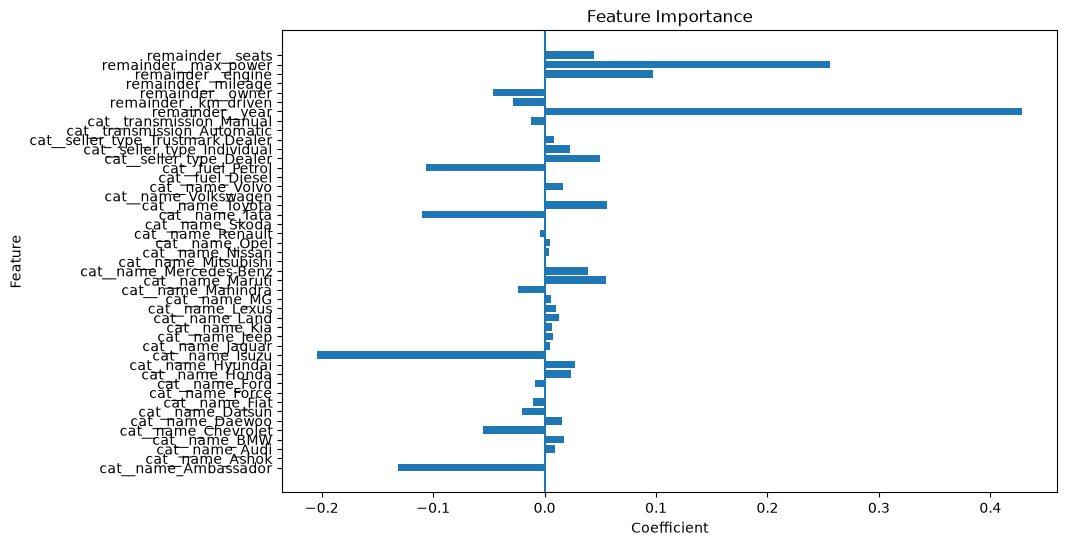

In [100]:
# ==========================================
# Test Set Prediction using Best Model
# ==========================================

from joblib import load
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the saved best model and the exact fitted preprocessing objects used for training.
l_model = load("models/car_price_model2.pkl")
fold_preprocessor = load("models/car_price_model2_preprocessor.pkl")
fold_scaler = load("models/car_price_model2_scaler.pkl")

# Apply the same transformation pipeline used during training.
X_test_preprocess = fold_preprocessor.transform(X_test).toarray()
X_test_preprocess = fold_scaler.transform(X_test_preprocess)

# Add the intercept term expected by the custom model
X_test_preprocess = np.column_stack([
    np.ones(X_test_preprocess.shape[0]),
    X_test_preprocess
])

# Predict on test set
y_pred_log = l_model.predict(X_test_preprocess)

# Convert from log price back to original price
y_pred = np.exp(y_pred_log)
y_test_original = np.exp(y_test.to_numpy())

# Calculate evaluation metrics
mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("Test Set Performance")
print("--------------------")
print(f"MSE: {mse:,.2f}")
print(f"R²:  {r2:.4f}")


# ==========================================
# Feature Importance
# ==========================================

feature_names = list(fold_preprocessor.get_feature_names_out())
l_model.feature_importance(feature_names)



# Final Report: Custom Car-Price Regression

The experiment compared the custom `Normal`, `Polynomial`, `Lasso`, and `Ridge` regression classes under different optimization settings. The target was transformed with `log(selling_price)`, categorical variables were one-hot encoded, and the resulting features were standardized. Each configuration used three outer cross-validation folds, while the custom model used two inner folds for validation and logged training and validation metrics to MLflow.

The strongest configuration was mini-batch Lasso with Xavier initialization, learning rate `0.01`, and no momentum. It achieved the highest mean validation $R^2$ of approximately `0.732`. Lasso also performed consistently well in the other stable configurations. The polynomial model was less reliable because the expanded feature space made the gradient-descent updates more sensitive to the learning rate and initialization. Momentum and the larger batch-learning settings were unstable for this dataset, producing negative validation $R^2$ values in several runs.

The selected Lasso model was retrained and evaluated on the held-out test set after applying the exact same fitted encoder and scaler. On the original price scale, it achieved an $R^2$ of approximately `0.8873` and an MSE of approximately `28,537,706,614`. The test-set result should be interpreted separately from the cross-validation scores because cross-validation was measured in log-price space, while the final test metrics were transformed back to the original currency scale.

In [105]:
# Final comparison tables
best_models_df

,key,model,r2
0,Mini_Without_Momentum,Lasso,0.453666
1,Mini_With_Momentum,Lasso,-3.170275
2,Mini_xavier,Normal,0.367475
3,Mini_xavier_lr01,Lasso,0.808668
4,Mini_xavier_lr0001,Lasso,-3.274353
5,batch_xavier_lr001,Normal,-108.459212
6,batch_stochastic_lr001,Lasso,0.748101


In [ ]:
# Final comparison tables
#configuration_comparison = pd.DataFrame([
#   ["Mini, zeros, lr=0.001, no momentum", "Lasso", 0.453142],
#    ["Mini, zeros, lr=0.001, momentum", "Lasso", -3.167564],
#    ["Mini, Xavier, lr=0.001, no momentum", "Normal", 0.384810],
#    ["Mini, Xavier, lr=0.01, no momentum", "Lasso", 0.732308],
#    ["Mini, Xavier, lr=0.0001, no momentum", "Lasso", -2.931800],
#    ["Batch, Xavier, lr=0.001, no momentum", "Lasso", -109.107697],
#    ["Stochastic, Xavier, lr=0.0001, no momentum", "Lasso", 0.710328],
#], columns=["Configuration", "Best model", "Mean validation R2"])




print("Final test result")
test_summary = pd.DataFrame([
    ["Lasso", "Original selling-price scale", float(mse), float(r2)]
], columns=["Selected model", "Evaluation scale", "MSE", "R2"])
display(test_summary.style.format({"MSE": "{:,.2f}", "R2": "{:.4f}"}))

Final held-out test result


,Selected model,Evaluation scale,MSE,R2
0,Lasso,Original selling-price scale,"34,006,892,841.46",0.8656
